# May 1972: Stability of a large system

By Isaac Gabriel Julio-Pereira (class of 2025)

In [1]:
#import packages
# import packages
import pandas as pd
import numpy as np
import random 
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [2]:
# function to plot matrices 

def plot_matrix(matrix, title="Matrix with Regular Color Scale", use_meta=False):
    """
    Normalize each row of a given matrix and plot a heatmap with a color scale.
    If 'meta' is present in the title, a custom red-to-green color scale is used; 
    otherwise, a regular color scale is used.

    Args:
        matrix (numpy.ndarray): Input 2D matrix.
        title (str): Title of the heatmap (used to decide the color scale).
        use_meta (bool): Flag to apply the custom color scale when True, 
                         or use a regular color scale otherwise.
    """
    # Normalize the matrix
    norm_conf = []
    for row in matrix:
        row_sum = sum(row)
        normalized_row = [float(val) / float(row_sum) if row_sum != 0 else 0 for val in row]
        norm_conf.append(normalized_row)
    normalized_matrix = np.array(norm_conf)

    # Define custom color scale (red-to-green)
    custom_colorscale = [
        [0, 'darkred'],   # Dark red for negative values
        [0.4999, 'red'],  # Red for negative values
        [0.5, 'white'],   # White for zero values
        [0.511111111, 'blue'],  # Blue for positive values
        [1, 'darkblue']  # Dark blue for positive values
    ]

    # Define regular color scale (default)
    regular_colorscale = 'Viridis'  # You can use any built-in color scale, e.g., 'Viridis', 'Cividis', etc.

    # Select color scale based on the flag or title
    colorscale = custom_colorscale if use_meta or 'meta' in title.lower() else regular_colorscale

    # Create the heatmap
    fig = go.Figure(data=go.Heatmap(
        z=matrix,  # Use the original matrix
        x=np.arange(1, matrix.shape[1] + 1),
        y=np.arange(1, matrix.shape[0] + 1),  # Reverse the y-axis labels
        colorscale=colorscale,
        zmid=0,  # Set the midpoint of the color scale to zero
        showscale=True  # Display color scale
    ))

    # Ensure figure appears square
    fig.update_layout(
        title=title,
        xaxis_title='Column',
        yaxis_title='Row',
        yaxis=dict(scaleanchor="x", autorange='reversed'),  # Keep aspect ratio square
        width=1000,  # Adjust width
        height=1000,  # Adjust height to match width
    )

    # Show the plot
    fig.show()

    return  # Return normalized matrix if needed



## Function to sample local communities

### Parameters

S= Number of Species

C=Connectivity

$\sigma$= Standard deviation of interaction strength 

s = self-regulation coefficient or intraspecific competition


We will create matrix **A**, with dimensions *S* * *S*. The matrix **A** will contain all the interactions between species. The effect of species _i_ on species _j_ is will be on the off diagonal. The diagonal of matrix __A__ will be set to -s. The matrix __A__ elements will be the following:

$$a_{ij}= N(0,\sigma^2)$$
$$a_{ii}=-s$$

Refrences

Coyte, K. Z., Schluter, J., & Foster, K. R. (2015).Science, 350(6261), 663–666. http://doi.org/10.1126/science.aad2602

May, R. M. (1972). Will a large complex system be stable? Nature, 238(5364), 413–414.

In [3]:
def local_community_May(S,C, sigma,s):
    # S= number of species
    # C= connectivity among species in the local community
    # sigma= interaction strength

    A= np.zeros((S,S)) # create a SxS matrix of zeros

    np.fill_diagonal(A, -s) # fill the diagonal with -s

    for i in range(1,S):
        for j in range(i):
            if random.random() < C: # if a random number between 0 and 1 is less than C, then there is an interaction between species i and j
                a = sigma*(np.random.normal(0,1))
                b = sigma*(np.random.normal(0,1))
                A[i,j]= a # fill the interaction with a random number from a normal distribution with mean 0 and standard deviation 1
                A[j,i]= b # fill the interaction with a random number from a normal distribution with mean 0 and standard deviation 1

    return A

In [4]:
#Test the function
S= 150 # number of species
C= 0.5 # connectivity among species in the local community
sigma= 0.1 # interaction strength
s= 1 # self-regulation coefficient or intraspecific competition
A= local_community_May(S,C, sigma,s)
print(A)
plot_matrix(A, title="May 1972 Model Interaction Matrix", use_meta=True)

[[-1.          0.         -0.09975529 ... -0.19747647 -0.13883198
   0.        ]
 [ 0.         -1.          0.04245699 ... -0.00496138 -0.04542772
  -0.07074264]
 [-0.05932918 -0.01543097 -1.         ...  0.21599821  0.
   0.        ]
 ...
 [-0.02594356  0.19846008 -0.13378048 ... -1.          0.
   0.04851057]
 [-0.22181858  0.0135037   0.         ...  0.         -1.
   0.02086821]
 [ 0.          0.09166959  0.         ... -0.09681764 -0.02359704
  -1.        ]]


In [5]:
# function for eigenvalues

def max_real_eigenvalue(matrix, plot=False):
    """
    Calculate the maximum real part of the eigenvalues of a matrix.
    
    Parameters:
    matrix (np.ndarray): The input matrix.
    
    Returns:
    float: The maximum real part of the eigenvalues.
    """

    if plot:
        eigenvalues = np.linalg.eigvals(matrix)
        plt.figure(figsize=(8, 6))
        plt.scatter(np.real(eigenvalues), np.imag(eigenvalues), color='blue', marker='o')
        plt.axvline(0, color='red', linestyle='--')  # Vertical line at Re=0
        plt.axhline(0, color='black', linestyle='--')  # Horizontal line at Im=0
        plt.title('Eigenvalue Spectrum')
        plt.xlabel('Real Part')
        plt.ylabel('Imaginary Part')
        plt.grid()
        plt.show()
        max_real_part = np.max(np.real(eigenvalues))
        return print(max_real_part, "is the maximum real part of the eigenvalues")
    else:
        eigenvalues = np.linalg.eigvals(matrix)
        max_real_part = np.max(np.real(eigenvalues))
        return max_real_part




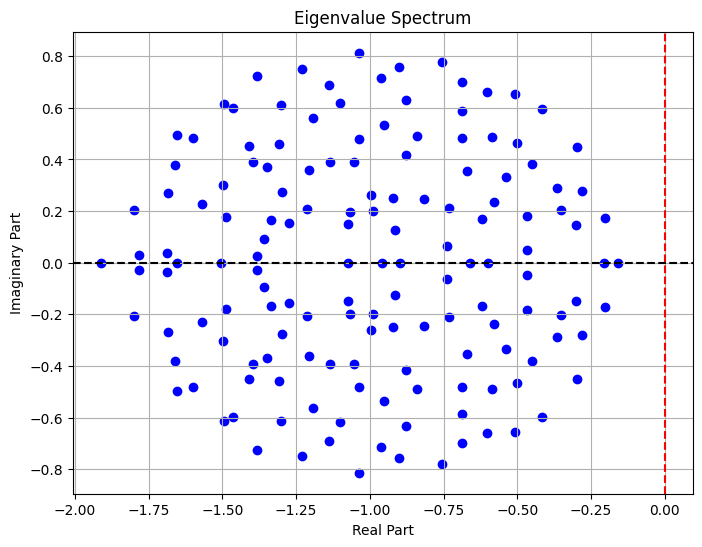

-0.15805885531183275 is the maximum real part of the eigenvalues


In [6]:
max_real_eigenvalue(A, plot=True)


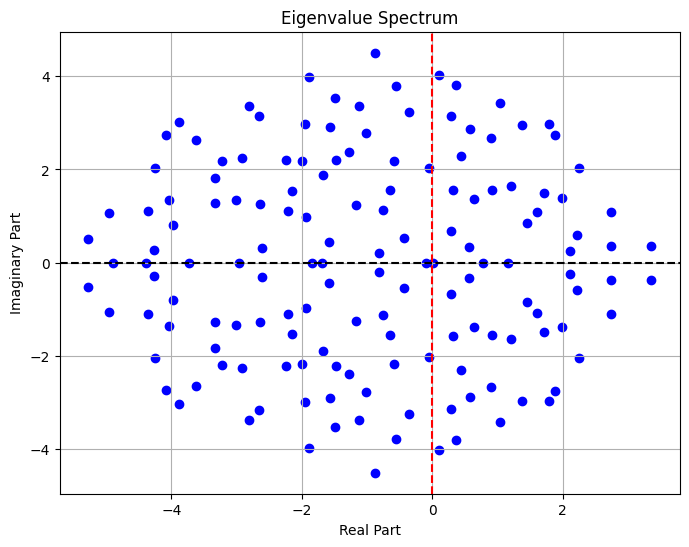

3.3631879339353614 is the maximum real part of the eigenvalues


In [7]:
#Play with values
S= 150 # number of species
C= 0.5 # connectivity among species in the local community
sigma= 0.5 # interaction strength
s= 1 # self-regulation coefficient or intraspecific competition
A1= local_community_May(S,C, sigma,s)
max_real_eigenvalue(A1, plot=True)



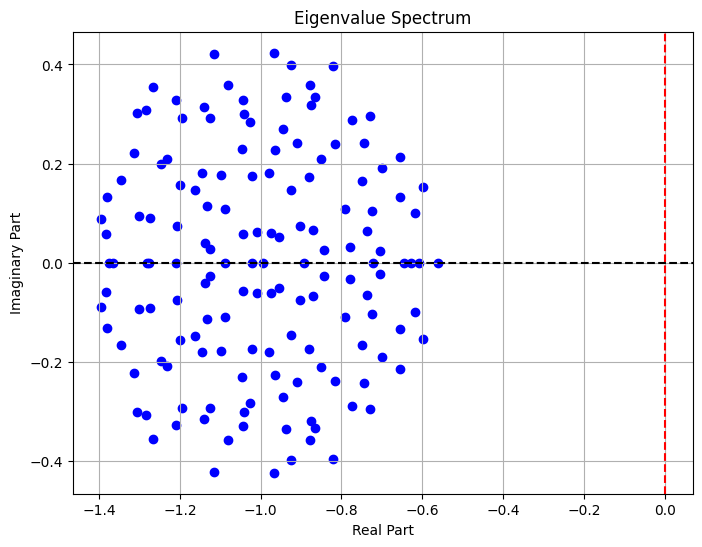

-0.5606457827664139 is the maximum real part of the eigenvalues


In [8]:
#Play with values
S= 150 # number of species
C= 0.5 # connectivity among species in the local community
sigma= 0.05 # interaction strength
s= 1 # self-regulation coefficient or intraspecific competition
A2= local_community_May(S,C, sigma,s)
max_real_eigenvalue(A2, plot=True)



### May's stability criterion

$$\sigma< \frac{1}{\sqrt{S*C}}$$

This inequality shows the trade off between interaction strength, connectivity and number of species

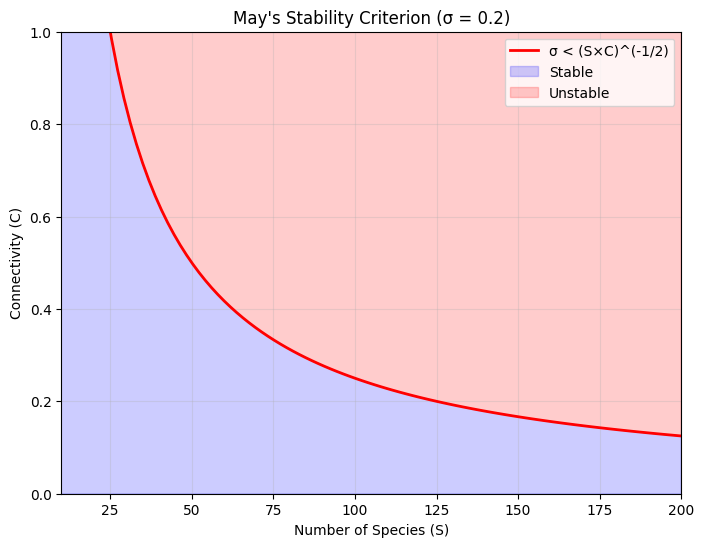

In [9]:
# Plot May's stability criterion: σ < (S × C)^(-1/2)
# Rearranged as: C < σ^(-2) / S

sigma = 0.2  # Fixed interaction strength
S = np.linspace(10, 200, 100)  # Number of species
C_boundary = (sigma**(-2)) / S  # Stability boundary

plt.figure(figsize=(8, 6))
plt.plot(S, C_boundary, 'r-', linewidth=2, label=f'σ < (S×C)^(-1/2)')
plt.fill_between(S, 0, C_boundary, alpha=0.2, color='blue', label='Stable')
plt.fill_between(S, C_boundary, 1, alpha=0.2, color='red', label='Unstable')

plt.xlabel('Number of Species (S)')
plt.ylabel('Connectivity (C)')
plt.title(f'May\'s Stability Criterion (σ = {sigma})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(10, 200)
plt.ylim(0, 1)
plt.show()

# The math behind May's reasoning

Let's model a local community using a generalized Lotka-Volterra model

$$ \frac{dN_i}{dt}= r_i N_i+ a_{ii}N_i^2+\sum^{S}_{i=1} a_{ij}N_jN_i$$

$N_i$ = abundance of species $i$ 

$r_i$ = intrinsic growth rate of species $i$

$a_{ij}$ = the effect of species $j$ on species $i$

$a_{ii}$ = self regulation coefficient

### Before anything lets solve for $N_i^*$

$$ \frac{dN_i}{dt}= r_i N_i+ a_{ii}N_i^2+\sum^{S}_{i=1} a_{ij}N_jN_i$$

divide by $N_i$

$$ \frac{1}{N_i}\frac{dN_i}{dt}= r_i + a_{ii}N_i+\sum^{S}_{i=1} a_{ij}N_j$$

set $\frac{dN_i}{dt} =0$

$$ 0= r_i + a_{ii}N_i+\sum^{S}_{i=1} a_{ij}N_j$$

Convert to matrix form:

$$ \mathbf{r} + \mathbf{A}\mathbf{N} = 0 $$

Solve for $\mathbf{N}$

$$ \mathbf{N}= -\mathbf{A}^{-1}\mathbf{r} $$

This is important for feasibility, which spoiler alert, he did not 



###  Deriving the Jacobian 
We want to know the stability for this system. We can determine local stability by computing the Jacobian and extracting its eigenvalues. This is what May in fact did in gis paper. However, he used the per capita version of the GLV, not "normal" version of the GLV



$$ \frac{\partial f_i}{\partial N_j} \quad \text{for}  \quad \text{off-diagonal}$$

$$ \frac{\partial f_i}{\partial N_i} \quad \text{for} \quad \text{diagonal}$$


This formulation shows how each element of the Jacobian is computed for both diagonal and off-diagonal cases.

Lets solve the diagonal

$$ \frac{\partial f_i}{\partial N_j} =r_i N_i+ a_{ii}N_i^2+\sum^{S}_{i=1} a_{ij}N_jN_i$$

$$ \frac{\partial f_i}{\partial N_j} =r_i + 2a_{ii}N_i + \sum_{j=1}^S a_{ij}N_j$$

Evaluate at equilibrium $N_i^*$:

$$ \left.\frac{\partial f_i}{\partial N_j}\right|_{N_i^*} =r_i + 2a_{ii}N_i + \sum_{j=1}^S a_{ij}N_j$$


At equilibrium we know that $ 0= r_i + a_{ii}N_i+\sum^{S}_{i=1} a_{ij}N_j$. a little magic and $ r_i+ \sum^{S}_{i=1} a_{ij}N_j=  -a_{ii}N_i$, which we use to replace

$$ \left.\frac{\partial f_i}{\partial N_j}\right|_{N_i^*} = 2a_{ii}N_i - a_{ii}N_i$$

Evaluate at equilibrium $N_i^*$

$$ \left.\frac{\partial f_i}{\partial N_j}\right|_{N_i^*} = a_{ii}N_i^*$$


Lets solve off-diagonal


$$ \frac{\partial f_i}{\partial N_j} =r_i + 2a_{ii}N_i + \sum_{j=1}^S a_{ij}N_j$$


$$ \frac{\partial f_i}{\partial N_j} =a_{ij}N_j$$

Evaluate at equilibrium $N_j^*$

$$ \left.\frac{\partial f_i}{\partial N_j}\right|_{N_j^*} = a_{ij}N_i^*$$

The Jacobian derivation above was a correction that imposed feasibility criterion $(N_i^*>0)$ which have similar results to the original work by May. 

#### May's Jacobian

In May's paper he divided by $N_i$ which would have resulted in $ \left.\frac{1}{N_i}\frac{\partial f_i}{\partial N_j}\right|_{N_j^*} = a_{ii}$ and $ \left.\frac{1}{N_i}\frac{\partial f_i}{\partial N_j}\right|_{N_j^*} = a_{ij}$ for diagonal and off-diagonal respectively.

Therefore what determines the system's stability is the $ \mathbf{A}$ with elements $a_{ij}$




## When does this framework falls apart? 
#### Adding structure to a local community
$P_m$ = proportion of mutualistic interaction (+/+)

$P_c$ =proportion of competitive interaction (-/-)

$P_e$= proportion of exploitative interaction (+/-)

$P_m+P_c+P_e=1$

When the community has $P_m=1$ and strong species interation its determine to be unstable, however, the system is unfeasible to begin with. There is no point in determining the stability of an unfeasible system, specially if it has negative abundances. I would code it, but I ran out of motivation.
